In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import h5py

In [2]:
from rc import ESN, ESNConfig

In [3]:

with h5py.File('../data_eigenworm/crawl.mat', 'r') as f:
    tr_refs = f['tr'][1]
    print(f"tr shape: {tr_refs.shape}")
    
    tr_data = []
    for ref in tr_refs.flatten():
        data = f[ref][:]
        tr_data.append(data)
        print(f"Data shape: {data.shape}")


tr shape: (1,)
Data shape: (5, 33600)


In [4]:
def filter_nans(pcs):
    nan_mask = np.isnan(pcs).any(axis=0)
    
    valid_indices = np.where(~nan_mask)[0]
    
    indexes_to_skip = []
    for i in range(1, len(valid_indices)):
        if valid_indices[i] - valid_indices[i-1] > 1:
            indexes_to_skip.append(i)
    
    filtered_pcs = pcs[:, ~nan_mask]
    
    return filtered_pcs, indexes_to_skip
all_pcs = []
all_skip_indices = [] 
current_index = 0

for i in range(len(tr_data)):  
    filtered_pcs, gap_indices = filter_nans(tr_data[i][:5, :])
    
    for idx in gap_indices:
        all_skip_indices.append(idx + current_index)
    
    all_pcs.append(filtered_pcs)
    current_index += filtered_pcs.shape[1]
    
    if i < len(tr_data) - 1:
        all_skip_indices.append(current_index)

all_pcs = np.hstack(all_pcs)

In [5]:
worm_N2_scaled = StandardScaler().fit_transform(all_pcs.T).T

In [6]:
dt = 1/16

In [7]:
config = ESNConfig(
    N=10000,
    input_dim=5,
    spectral_radius=0.1809616855907689,
    alpha=1.5,
    sparsity=0.99,
    input_scaling=1.2665236214415563,
    bias_scaling=0.01,
    seed=None,
    mode='leaky',
    leaky_rate=0.7057809844406092,
)

In [8]:
config

ESNConfig(N=10000, input_dim=5, spectral_radius=0.1809616855907689, alpha=1.5, sparsity=0.99, input_scaling=1.2665236214415563, bias_scaling=0.01, seed=None, weights_generation_strategy='Gaussian', bias_generation_strategy='Uniform', input_generation_strategy='Uniform', self_connections=False, dtype=dtype('float64'), mode='leaky', leaky_rate=0.7057809844406092, beta=0.5, scale=0.1)

In [38]:
worm_N2_scaled_resampled = worm_N2_scaled[:, ::2]

In [9]:
inputdim = 5
esn = ESN(config)
esn.train(worm_N2_scaled[:inputdim, :], washout=2000)


KeyboardInterrupt: 

In [ ]:
esn_resampled = ESN()
esn_resampled.load("/Users/iliasoroka/RC/esn_resampled.pkl.npz")
esn_resampled.train(worm_N2_scaled_resampled[:inputdim, :], washout=2000)


In [53]:
esn_resampled.load("/Users/iliasoroka/RC/esn_resampled.pkl.npz")

In [81]:
warmup_data_resampled = worm_N2_scaled_resampled[:inputdim, :2000]
predictions, states = esn_resampled.predict(warmup_data_resampled, steps=5000)

NameError: name 'esn_resampled' is not defined

In [43]:
warmup_data = worm_N2_scaled[:inputdim, 2000:4000]
predictions, states = esn.predict(warmup_data, steps=10000)

In [44]:
read_data_slice = worm_N2_scaled[:inputdim, 4000:14000]

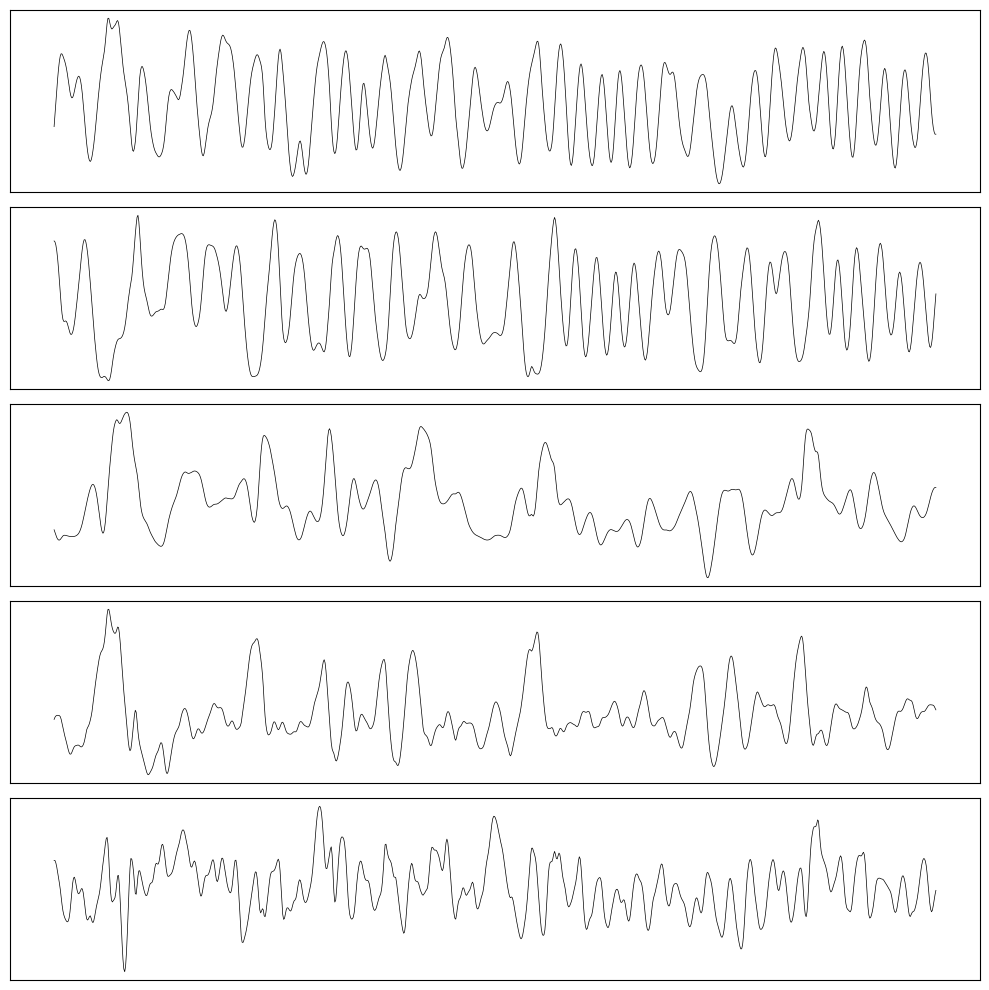

In [45]:
fig, axes = plt.subplots(5, 1, figsize=(10, 10))

for i in range(5):
    axes[i].plot(read_data_slice[i, :1000], linewidth=0.5, color='black')
    # axes[i].set_ylabel(f'Dim {i}')
    axes[i].set_xticks([])
    axes[i].set_yticks([])
    axes[i].set_xlabel('')

plt.tight_layout()
plt.savefig('read_data_slice.svg', format='svg', transparent=True)
plt.savefig('read_data_slice.pdf', format='pdf', bbox_inches='tight')
plt.show()


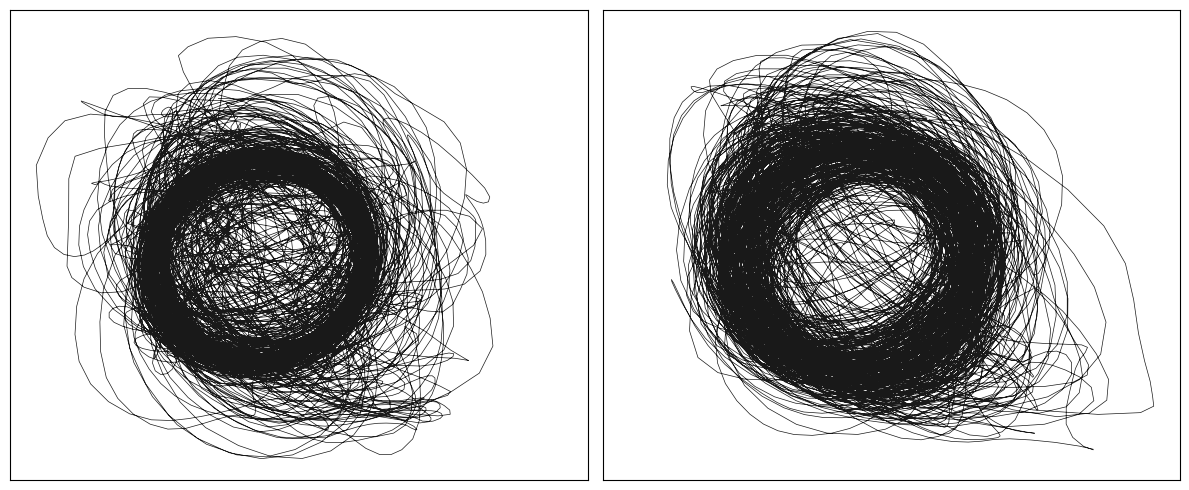

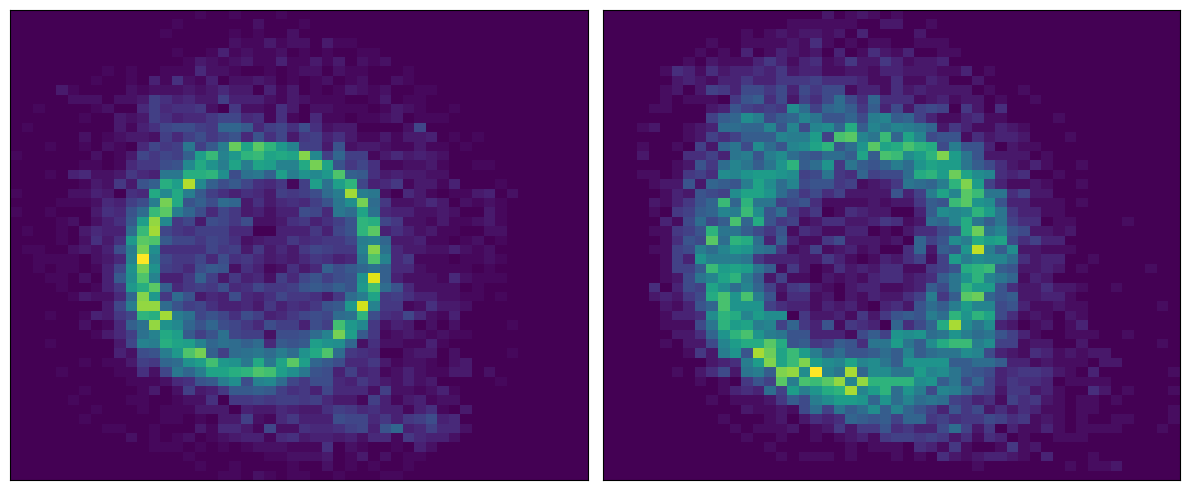

In [46]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

x_min = min(predictions[0, :].min(), read_data_slice[0, :].min())
x_max = max(predictions[0, :].max(), read_data_slice[0, :].max())
y_min = min(predictions[1, :].min(), read_data_slice[1, :].min())
y_max = max(predictions[1, :].max(), read_data_slice[1, :].max())

x_padding = (x_max - x_min) * 0.05
y_padding = (y_max - y_min) * 0.05

ax1.plot(predictions[0, :], predictions[1, :], 'black', linewidth=0.5, alpha=0.9)

ax1.set_xlim(x_min - x_padding, x_max + x_padding)
ax1.set_ylim(y_min - y_padding, y_max + y_padding)
ax1.set_xticks([])
ax1.set_yticks([])

ax2.plot(read_data_slice[0, :], read_data_slice[1, :], 'black', linewidth=0.5, alpha=0.9)

ax2.set_xlim(x_min - x_padding, x_max + x_padding)
ax2.set_ylim(y_min - y_padding, y_max + y_padding)
ax2.set_xticks([])
ax2.set_yticks([])

plt.tight_layout()
# plt.savefig('prediction_vs_real.svg', format='svg', transparent=True)
# plt.savefig('prediction_vs_real.pdf', format='pdf', bbox_inches='tight')
plt.show()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

x_min = min(predictions[0, :].min(), read_data_slice[0, :].min())
x_max = max(predictions[0, :].max(), read_data_slice[0, :].max())
y_min = min(predictions[1, :].min(), read_data_slice[1, :].min())
y_max = max(predictions[1, :].max(), read_data_slice[1, :].max())

ax1.hist2d(predictions[0, :], predictions[1, :], bins=50, range=[[x_min, x_max], [y_min, y_max]])
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)
ax1.set_xticks([])
ax1.set_yticks([])

ax2.hist2d(read_data_slice[0, :], read_data_slice[1, :], bins=50, range=[[x_min, x_max], [y_min, y_max]])
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)
ax2.set_xticks([])
ax2.set_yticks([])

plt.tight_layout()
# plt.savefig('histogram_prediction.svg', format='svg', transparent=True)
# plt.savefig('histogram_real.svg', format='svg', transparent=True)
plt.show()

In [ ]:
spectrum_11 = esn.lyapunov_spectrum(worm_N2_scaled[:inputdim, 2000:], 20, 2500, 2, 1/16, 2, 2000, 500, False)

In [194]:
spectrum_11

{'mean': array([  0.44483757,   0.15561449,  -0.0196263 ,  -0.24651517,
         -0.58737427,  -0.97923908,  -1.53259712,  -2.24590601,
         -3.70640881,  -4.59537752,  -6.06369305,  -6.60755962,
         -7.17751546, -13.18771714, -14.14907079, -16.24792288,
        -16.2614284 , -16.26491728, -16.26972117, -16.27591257]),
 'std': array([0.01866292, 0.03594992, 0.00588497, 0.01256441, 0.05146395,
        0.00524311, 0.02873766, 0.08803605, 0.18312514, 0.1538319 ,
        0.24053074, 0.14542273, 0.2488772 , 0.02872704, 0.09850199,
        0.03425033, 0.02438958, 0.02682684, 0.03137753, 0.03142114]),
 'all_samples': array([[ 4.26174645e-01,  1.91564405e-01, -1.37413319e-02,
         -2.59079582e-01, -6.38838221e-01, -9.73995968e-01,
         -1.56133478e+00, -2.33394206e+00, -3.88953395e+00,
         -4.74920942e+00, -6.30422379e+00, -6.75298235e+00,
         -7.42639266e+00, -1.32164442e+01, -1.42475728e+01,
         -1.62858180e+01, -1.62821732e+01, -1.62917441e+01,
         -1.63

In [ ]:
spectrum_resampled = esn_resampled.lyapunov_spectrum(worm_N2_scaled_resampled[:inputdim, 2000:], 20, 2500, 1, 2/16, 1, 2000, 500, False)

In [173]:
spectrum = esn.lyapunov_spectrum(worm_N2_scaled[:5, 2000:], 20, 4500, 2, 1/16, 5, 2000, 500, False)

In [2]:
import pickle

with open('/Users/iliasoroka/ReservoirComputing/results_data/spectrum.pkl', 'rb') as f:
    spectrum_1 = pickle.load(f)

In [3]:
spectrum_1

{'mean': array([ 7.08974610e-01,  2.42320109e-01,  4.05161052e-03, -2.15099287e-01,
        -5.87733678e-01, -1.07464417e+00, -1.65300763e+00, -2.31251915e+00,
        -3.23787708e+00, -4.47262878e+00, -5.90416130e+00, -6.65752845e+00,
        -7.19350984e+00, -1.14326151e+01, -1.32602250e+01, -1.61875325e+01,
        -1.62008310e+01, -1.62122037e+01, -1.62132207e+01, -1.62194188e+01]),
 'std': array([0.10424236, 0.07686225, 0.02803245, 0.06006936, 0.05924392,
        0.07808707, 0.14271411, 0.13930264, 0.23094478, 0.31742409,
        0.21069004, 0.29175432, 0.32616875, 0.1806267 , 0.1397625 ,
        0.03687436, 0.03512281, 0.03546906, 0.03798476, 0.03897983]),
 'all_samples': array([[ 7.97029719e-01,  3.22324877e-01, -1.54959764e-02,
         -2.48776377e-01, -6.39409347e-01, -1.07996660e+00,
         -1.83200487e+00, -2.40158850e+00, -3.50521394e+00,
         -4.50339021e+00, -5.94382269e+00, -6.83798227e+00,
         -7.33018973e+00, -1.14854848e+01, -1.33495761e+01,
         -1.61

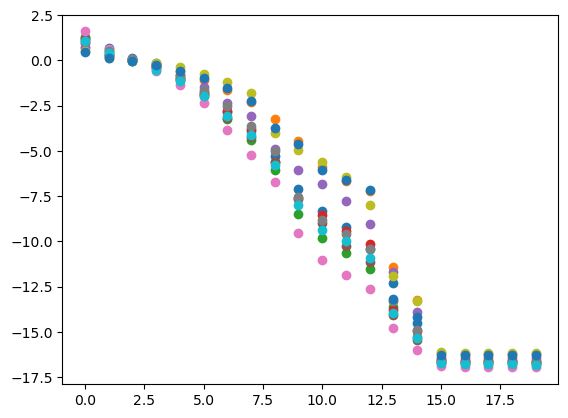

In [195]:
plt.plot(spectrum['mean'], 'o')
plt.plot(spectrum_1['mean'], 'o')
plt.plot(spectrum_2['mean'], 'o')
plt.plot(spectrum_3['mean'], 'o')
plt.plot(spectrum_4['mean'], 'o')
plt.plot(spectrum_6['all_samples'][1], 'o')
plt.plot(spectrum_7['mean'], 'o')
plt.plot(spectrum_8['mean'], 'o')
plt.plot(spectrum_9['mean'], 'o')
plt.plot(spectrum_10['all_samples'][1], 'o')
plt.plot(spectrum_11['mean'], 'o')
plt.show()

In [ ]:
import pickle

spectra_list = [
    spectrum,
    spectrum_1,
    spectrum_2,
    spectrum_3,
    spectrum_4,
    spectrum_6,
    spectrum_7,
    spectrum_8,
    spectrum_9,
    spectrum_10,
    spectrum_11,
]

with open('/Users/iliasoroka/ReservoirComputing/spectra_list.pkl', 'wb') as f:
    pickle.dump(spectra_list, f)


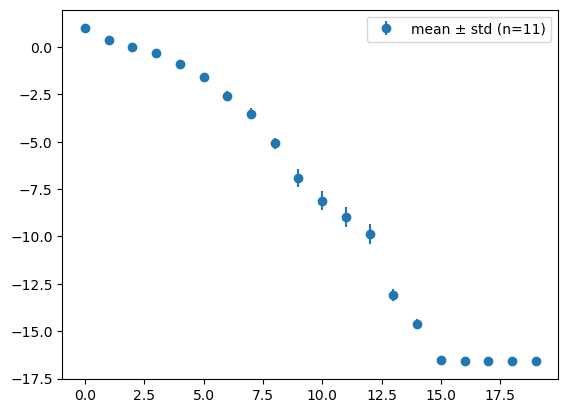

In [ ]:
import numpy as np

means_list = [
    spectrum['mean'],
    spectrum_1['mean'],
    spectrum_2['mean'],
    spectrum_3['mean'],
    spectrum_4['mean'],
    spectrum_6['all_samples'][1],
    spectrum_7['mean'],
    spectrum_8['mean'],
    spectrum_9['mean'],
    spectrum_10['all_samples'][1],
    spectrum_11['mean'],
]

means_arr = np.vstack(means_list)
mean_of_means = np.mean(means_arr, axis=0)
std_of_means = np.std(means_arr, axis=0)

plt.errorbar(
    np.arange(len(mean_of_means)),
    mean_of_means,
    yerr=std_of_means/np.sqrt(11),
    fmt='o',
    label='mean ± std '
)

plt.legend()
plt.show()

In [ ]:
lyap_exponents = spectrum['mean']
cumulative_sum = 0
j = -1

for i, exp in enumerate(lyap_exponents):
    cumulative_sum += exp
    if cumulative_sum >= 0:
        j = i
    else:
        break

if j >= 0 and j < len(lyap_exponents) - 1:
    sum_up_to_j = np.sum(lyap_exponents[:j+1])
    ky_dimension = j + 1 + sum_up_to_j / abs(lyap_exponents[j + 1])
elif j >= 0:
    ky_dimension = j + 1
else:
    ky_dimension = 0

print(f"Kaplan-Yorke dimension: {ky_dimension}")
ky_dimension

Kaplan-Yorke dimension: 6.279498994680238


np.float64(6.279498994680238)

In [127]:
conditional_lyapunov_spectrum

{'exponents': array([-7.84495696]),
 'convergence': None,
 'max_cle': np.float64(-7.844956962748173),
 'sum_cle': np.float64(-7.844956962748173),
 'num_renorms': 13685}

In [111]:
esn_resampled.save('esn_resampled.pkl')

In [ ]:
with open('spectrum.pkl', 'wb') as f:
    pickle.dump(spectrum, f)

spectrum

{'mean': array([ 7.08974610e-01,  2.42320109e-01,  4.05161052e-03, -2.15099287e-01,
        -5.87733678e-01, -1.07464417e+00, -1.65300763e+00, -2.31251915e+00,
        -3.23787708e+00, -4.47262878e+00, -5.90416130e+00, -6.65752845e+00,
        -7.19350984e+00, -1.14326151e+01, -1.32602250e+01, -1.61875325e+01,
        -1.62008310e+01, -1.62122037e+01, -1.62132207e+01, -1.62194188e+01]),
 'std': array([0.10424236, 0.07686225, 0.02803245, 0.06006936, 0.05924392,
        0.07808707, 0.14271411, 0.13930264, 0.23094478, 0.31742409,
        0.21069004, 0.29175432, 0.32616875, 0.1806267 , 0.1397625 ,
        0.03687436, 0.03512281, 0.03546906, 0.03798476, 0.03897983]),
 'all_samples': array([[ 7.97029719e-01,  3.22324877e-01, -1.54959764e-02,
         -2.48776377e-01, -6.39409347e-01, -1.07996660e+00,
         -1.83200487e+00, -2.40158850e+00, -3.50521394e+00,
         -4.50339021e+00, -5.94382269e+00, -6.83798227e+00,
         -7.33018973e+00, -1.14854848e+01, -1.33495761e+01,
         -1.61

In [112]:
with open('spectrum_resampled.pkl', 'wb') as f:
    pickle.dump(spectrum_resampled, f)


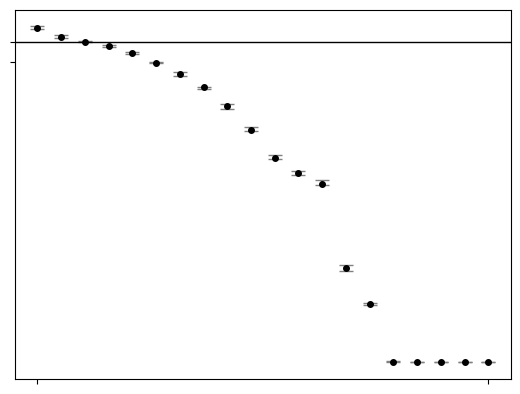

In [ ]:
plt.figure()

all_samples = spectrum_1['all_samples']
median_lyapunov = np.median(all_samples, axis=0)

n_bootstraps = 1000
bootstrap_medians = []
for _ in range(n_bootstraps):
    resample_idxs = np.random.choice(len(all_samples), len(all_samples), replace=True)
    resample = all_samples[resample_idxs]
    bootstrap_medians.append(np.median(resample, axis=0))

bootstrap_medians = np.array(bootstrap_medians)
ci_lower = np.percentile(bootstrap_medians, 2.5, axis=0)
ci_upper = np.percentile(bootstrap_medians, 97.5, axis=0)
yerr = np.array([median_lyapunov - ci_lower, ci_upper - median_lyapunov])

img = plt.errorbar(range(1, len(median_lyapunov) + 1), median_lyapunov,
                   yerr=yerr, fmt='k.', ms=8, capsize=5, 
                   ecolor='gray')
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
plt.xticks([1, len(median_lyapunov)], ['', ''])
plt.yticks([0, -1], ['', ''])
plt.minorticks_off()
plt.savefig('lyapunov_spectrum.svg', format='svg', transparent=True)
plt.savefig('lyapunov_spectrum.pdf', format='pdf', bbox_inches='tight')
plt.show()

plt.show()

In [15]:
for mean, lower, upper in zip(median_lyapunov, ci_lower, ci_upper):
    print(lower,mean, upper)

0.6423603557220399 0.7089746099892617 0.7844891744767808
0.21476109659438533 0.24232010855982722 0.34467484951357497
-0.015495976370431794 0.004051610517428807 0.029127404787090364
-0.24877637680560893 -0.215099286761746 -0.15389169139039988
-0.6198921179394538 -0.5877336775127486 -0.5351176423874776
-1.0835715401712587 -1.0746441737797066 -1.0243858668704364
-1.7161468737030474 -1.6530076251345494 -1.5483779984692156
-2.3756975214704714 -2.312519145179925 -2.265868035525476
-3.410631370221234 -3.237877077384561 -3.129535728537809
-4.507030471318319 -4.47262878064367 -4.295111032889537
-5.926727916808523 -5.904161300628219 -5.735968192052198
-6.7494053462171815 -6.65752845368681 -6.534396425850193
-7.257363013460825 -7.193509843858256 -7.009253178732176
-11.598230436471518 -11.432615125545729 -11.323684114568525
-13.349576130034794 -13.260224969057441 -13.24361760330231
-16.19054680146511 -16.187532510050822 -16.16291713479614
-16.21689495131912 -16.20589002251221 -16.192400729492952
-

In [ ]:
def calculate_ky_dimension(lyapunov_exponents):
    sorted_exps = np.sort(lyapunov_exponents)[::-1]
    
    cumsum = np.cumsum(sorted_exps)
    
    j = np.where(cumsum >= 0)[0]
    
    if len(j) == 0:
        return 0.0
    
    j = j[-1]  
    
    if j == len(sorted_exps) - 1:
        return float(len(sorted_exps))
    
    sum_j = cumsum[j]
    lambda_j_plus_1 = abs(sorted_exps[j + 1])
    
    if lambda_j_plus_1 == 0:
        return float(j + 1)
    
    d_ky = (j + 1) + sum_j / lambda_j_plus_1
    
    return d_ky

ky_dimension = calculate_ky_dimension(spectrum_resampled['mean'])
print(f"Kaplan-Yorke dimension: {ky_dimension:.4f}")

ky_dimensions = []
for sample in spectrum_resampled['all_samples']:
    ky_dimensions.append(calculate_ky_dimension(sample))

ky_dimensions = np.array(ky_dimensions)
print(f"KY dimension (mean ± std): {np.mean(ky_dimensions):.4f} ± {np.std(ky_dimensions):.4f}")
print(f"KY dimension (median): {np.median(ky_dimensions):.4f}")


Kaplan-Yorke dimension: 5.1344
KY dimension (mean ± std): 5.0344 ± 0.5095
KY dimension (median): 5.1576


In [150]:
conditional_lyapunov_spectrum = esn.conditional_lyapunov_spectrum(worm_N2_scaled[:inputdim, :10000],
                                                        num_lyaps=1,
                                                        norm_time=2,
                                                        dt=1/16)

In [21]:
conditional_lyapunov_spectrum_resampled = esn_resampled.conditional_lyapunov_spectrum(worm_N2_scaled_resampled[:inputdim, :10000],
                                                        num_lyaps=1,
                                                        norm_time=2,
                                                        dt=2/16)

In [22]:
conditional_lyapunov_spectrum_resampled

{'exponents': array([-8.27043298]),
 'convergence': None,
 'max_cle': np.float64(-8.270432979187275),
 'sum_cle': np.float64(-8.270432979187275),
 'num_renorms': 3750}

In [154]:
conditional_lyapunov_spectrum

{'exponents': array([-16.78739055]),
 'convergence': None,
 'max_cle': np.float64(-16.78739055375376),
 'sum_cle': np.float64(-16.78739055375376),
 'num_renorms': 3750}

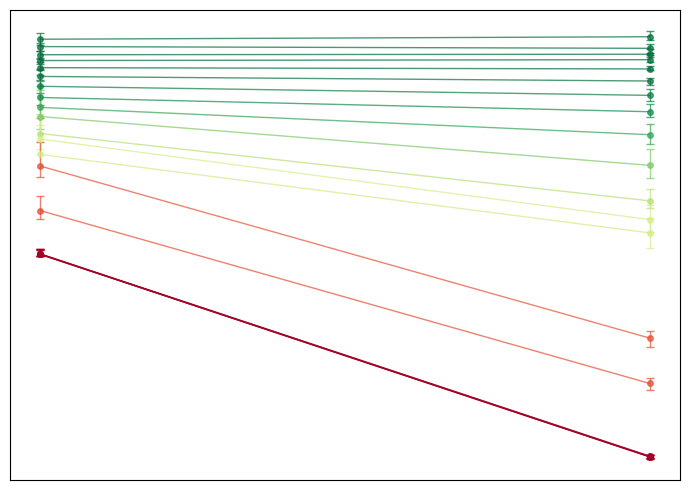

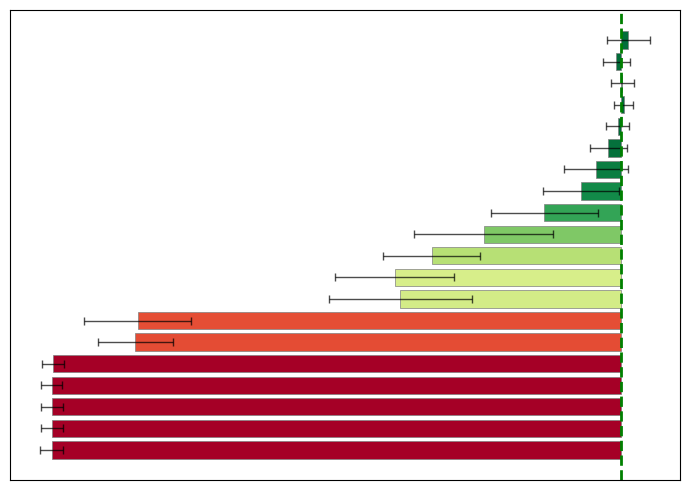

In [ ]:
fig1, ax1 = plt.subplots(1, 1, figsize=(7, 5))

dts = [1/16, 2/16]
spctrums = [[spectrum], [spectrum_resampled]]

num_exponents = len(spctrums[0][0]["mean"])

def bootstrap_ci(data, n_bootstrap=1000, ci=95):
    bootstrap_means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        bootstrap_means.append(np.median(sample))
    lower = np.percentile(bootstrap_means, (100 - ci) / 2)
    upper = np.percentile(bootstrap_means, 100 - (100 - ci) / 2)
    return lower, upper

all_data = []
inv_dts = [1/dt for dt in dts]

for exponent_idx in range(min(num_exponents, 40)):
    exponent_values = []
    exponent_errors_lower = []
    exponent_errors_upper = []
    
    for spectrum_list in spctrums:
        all_samples = [spectrum["all_samples"][:, exponent_idx] for spectrum in spectrum_list]
        all_samples_flat = np.concatenate(all_samples)
        
        median_val = np.median(all_samples_flat)
        lower = np.percentile(all_samples_flat, 2.5)
        upper = np.percentile(all_samples_flat, 97.5)
        
        exponent_values.append(median_val)
        exponent_errors_lower.append(abs(median_val - lower))
        exponent_errors_upper.append(abs(upper - median_val))
    
    exponent_errors = [exponent_errors_lower, exponent_errors_upper]
    all_data.append({'values': exponent_values, 'errors': exponent_errors})

slopes = []
slope_errors = []
for data in all_data:
    if len(inv_dts) >= 2:
        slope = (data['values'][-1] - data['values'][0]) / (inv_dts[-1] - inv_dts[0])
        
        n_bootstrap = 4000
        bootstrap_slopes = []
        for _ in range(n_bootstrap):
            sampled_values = []
            for i, val in enumerate(data['values']):
                std_err = (data['errors'][0][i] + data['errors'][1][i]) / (2 * 1.96)
                sampled_val = np.random.normal(val, std_err)
                sampled_values.append(sampled_val)
            
            boot_slope = (sampled_values[-1] - sampled_values[0]) / (inv_dts[-1] - inv_dts[0])
            bootstrap_slopes.append(boot_slope)
        
        slope_lower = np.percentile(bootstrap_slopes, 2.5)
        slope_upper = np.percentile(bootstrap_slopes, 97.5)
        slope_error = (slope_upper - slope_lower) / 2
    else:
        slope = 0
        slope_error = 0
    
    slopes.append(slope)
    slope_errors.append(slope_error)

max_abs_slope = max(abs(s) for s in slopes) if slopes else 1
slope_colors = plt.cm.RdYlGn_r(np.abs(slopes) / max_abs_slope)

for exponent_idx, data in enumerate(all_data):
    ax1.errorbar(inv_dts, data['values'], yerr=data['errors'], marker='o', markersize=4, linewidth=1, alpha=0.7, capsize=3, color=slope_colors[exponent_idx])

ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_xticklabels([])
ax1.set_yticklabels([])
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lyapunov_spectrum_dt_scaling.svg', format='svg', transparent=True)
plt.savefig('lyapunov_spectrum_dt_scaling.pdf', format='pdf', bbox_inches='tight')
plt.show()

fig2, ax2 = plt.subplots(1, 1, figsize=(7, 5))

y_positions = np.arange(len(slopes))
bars = ax2.barh(y_positions, slopes, xerr=slope_errors, color=slope_colors, edgecolor='gray', linewidth=0.5, capsize=3, error_kw={'elinewidth': 1, 'alpha': 0.7})

ax2.axvline(x=0, color='green', linestyle='--', linewidth=2)

ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_xticklabels([])
ax2.set_yticklabels([])
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

In [10]:
config = ESNConfig(
    N=2000,
    input_dim=5,
    spectral_radius=3,
    alpha=1.5,
    sparsity=0.99,
    input_scaling=1.2665236214415563,
    bias_scaling=0.01,
    seed=None,
    mode='leaky',
    leaky_rate=0.7057809844406092,
)

In [11]:
inputdim = 5
esn_wrong = ESN(config)
esn_wrong.train(worm_N2_scaled[:inputdim, :], washout=2000)

In [13]:
warmup_data = worm_N2_scaled[:inputdim, 2000:4000]
predictions, states = esn_wrong.predict(warmup_data, steps=10000)

In [14]:
read_data_slice = worm_N2_scaled[:inputdim, 4000:14000]

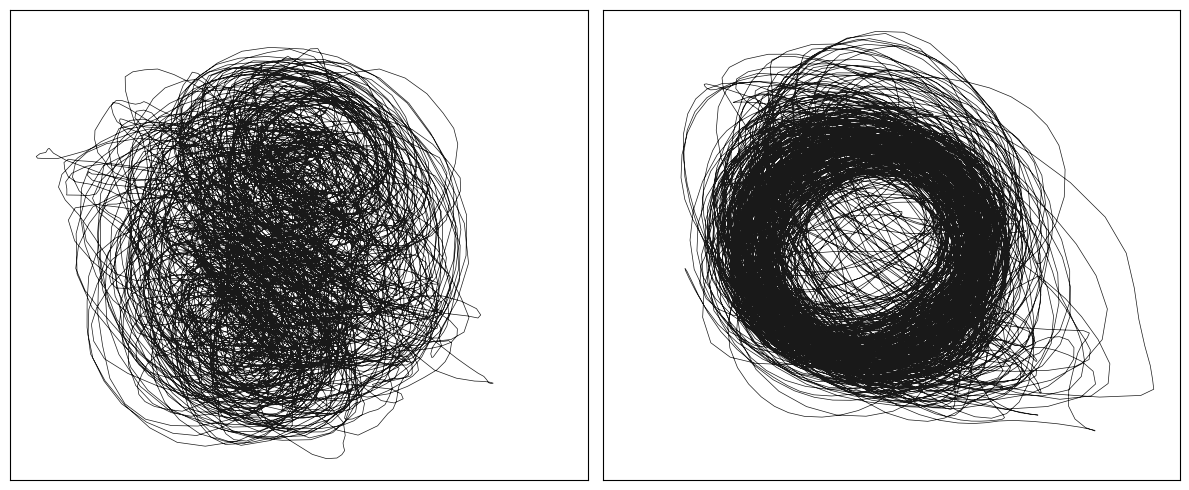

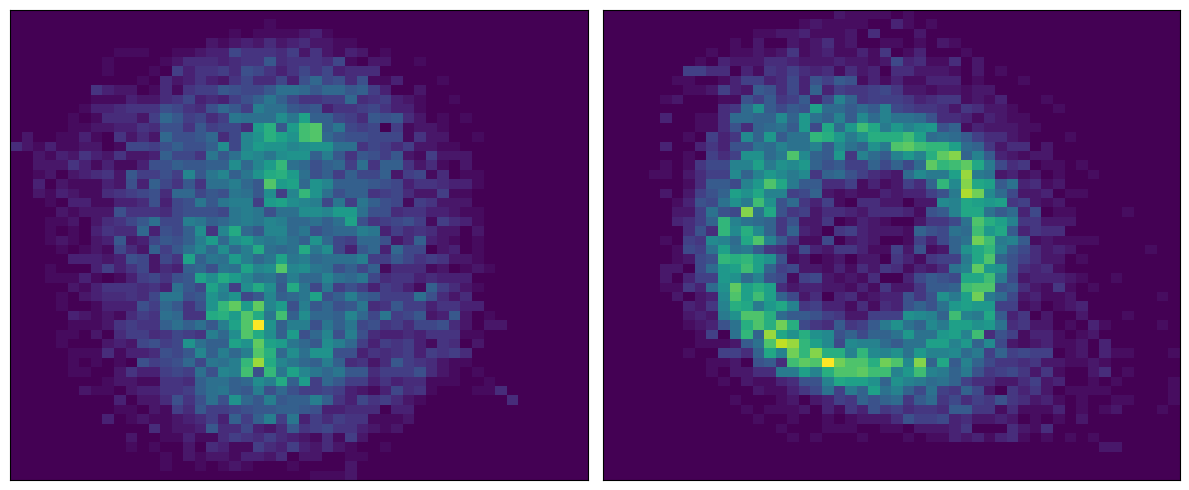

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

x_min = min(predictions[0, :].min(), read_data_slice[0, :].min())
x_max = max(predictions[0, :].max(), read_data_slice[0, :].max())
y_min = min(predictions[1, :].min(), read_data_slice[1, :].min())
y_max = max(predictions[1, :].max(), read_data_slice[1, :].max())

x_padding = (x_max - x_min) * 0.05
y_padding = (y_max - y_min) * 0.05

ax1.plot(predictions[0, :], predictions[1, :], 'black', linewidth=0.5, alpha=0.9)

ax1.set_xlim(x_min - x_padding, x_max + x_padding)
ax1.set_ylim(y_min - y_padding, y_max + y_padding)
ax1.set_xticks([])
ax1.set_yticks([])

ax2.plot(read_data_slice[0, :], read_data_slice[1, :], 'black', linewidth=0.5, alpha=0.9)

ax2.set_xlim(x_min - x_padding, x_max + x_padding)
ax2.set_ylim(y_min - y_padding, y_max + y_padding)
ax2.set_xticks([])
ax2.set_yticks([])

plt.tight_layout()
# plt.savefig('prediction_vs_real.svg', format='svg', transparent=True)
# plt.savefig('prediction_vs_real.pdf', format='pdf', bbox_inches='tight')
plt.show()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

x_min = min(predictions[0, :].min(), read_data_slice[0, :].min())
x_max = max(predictions[0, :].max(), read_data_slice[0, :].max())
y_min = min(predictions[1, :].min(), read_data_slice[1, :].min())
y_max = max(predictions[1, :].max(), read_data_slice[1, :].max())

ax1.hist2d(predictions[0, :], predictions[1, :], bins=50, range=[[x_min, x_max], [y_min, y_max]])
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)
ax1.set_xticks([])
ax1.set_yticks([])

ax2.hist2d(read_data_slice[0, :], read_data_slice[1, :], bins=50, range=[[x_min, x_max], [y_min, y_max]])
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)
ax2.set_xticks([])
ax2.set_yticks([])

plt.tight_layout()
# plt.savefig('histogram_prediction.svg', format='svg', transparent=True)
# plt.savefig('histogram_real.svg', format='svg', transparent=True)
plt.show()

In [16]:
import ot


In [ ]:
spectral_radii = np.linspace(0.1, 4.0, 30)
results = {
    'spectral_radii': [],
    'wasserstein_distances': [],
    'max_cle': [],
    'max_lyapunov': []
}

for g in spectral_radii:
    print(f"Training ESN with spectral radius g={g:.3f}")
    
    config_g = ESNConfig(
        N=2000,
        input_dim=inputdim,
        spectral_radius=g,
        alpha=1.5,
        sparsity=0.99,
        input_scaling=1.2665236214415563,
        bias_scaling=0.01,
        leaky_rate=0.7057809844406092,
        mode='leaky'
    )
    
    esn_g = ESN(config_g)
    esn_g.train(worm_N2_scaled[:inputdim, :], washout=2000)
    
    warmup_data = worm_N2_scaled[:inputdim, :2000]
    predictions_g, states_g = esn_g.predict(warmup_data, steps=5000)
    
    ref_segment = worm_N2_scaled[:inputdim, 2000:7000]  
    w_dist = ot.max_sliced_wasserstein_distance(ref_segment.T, predictions_g.T, n_projections=150)
    
    cle_result = esn_g.conditional_lyapunov_spectrum(worm_N2_scaled[:inputdim, :4000],
                                                        num_lyaps=1,
                                                        norm_time=2,
                                                        dt=1/16)
    max_cle_val = cle_result['max_cle']
    
    results['spectral_radii'].append(g)
    results['wasserstein_distances'].append(w_dist)
    results['max_cle'].append(max_cle_val)
    
    print(f"  Wasserstein: {w_dist:.4f}, Max CLE: {max_cle_val:.4f}")

Training ESN with spectral radius g=0.100
  Wasserstein: 0.5248, Max CLE: -18.2214
Training ESN with spectral radius g=0.234
  Wasserstein: 0.4247, Max CLE: -16.3629
Training ESN with spectral radius g=0.369
  Wasserstein: 1.1939, Max CLE: -14.6783
Training ESN with spectral radius g=0.503
  Wasserstein: 1.2721, Max CLE: -13.1643
Training ESN with spectral radius g=0.638
  Wasserstein: 0.5511, Max CLE: -11.7228
Training ESN with spectral radius g=0.772
  Wasserstein: 0.8073, Max CLE: -10.3420
Training ESN with spectral radius g=0.907
  Wasserstein: 0.6777, Max CLE: -9.2167
Training ESN with spectral radius g=1.041
  Wasserstein: 0.8691, Max CLE: -8.1430
Training ESN with spectral radius g=1.176
  Wasserstein: 0.8592, Max CLE: -7.1649
Training ESN with spectral radius g=1.310
  Wasserstein: 0.5984, Max CLE: -6.1970
Training ESN with spectral radius g=1.445
  Wasserstein: 0.8091, Max CLE: -5.4117
Training ESN with spectral radius g=1.579
  Wasserstein: 0.9353, Max CLE: -4.6926
Training E

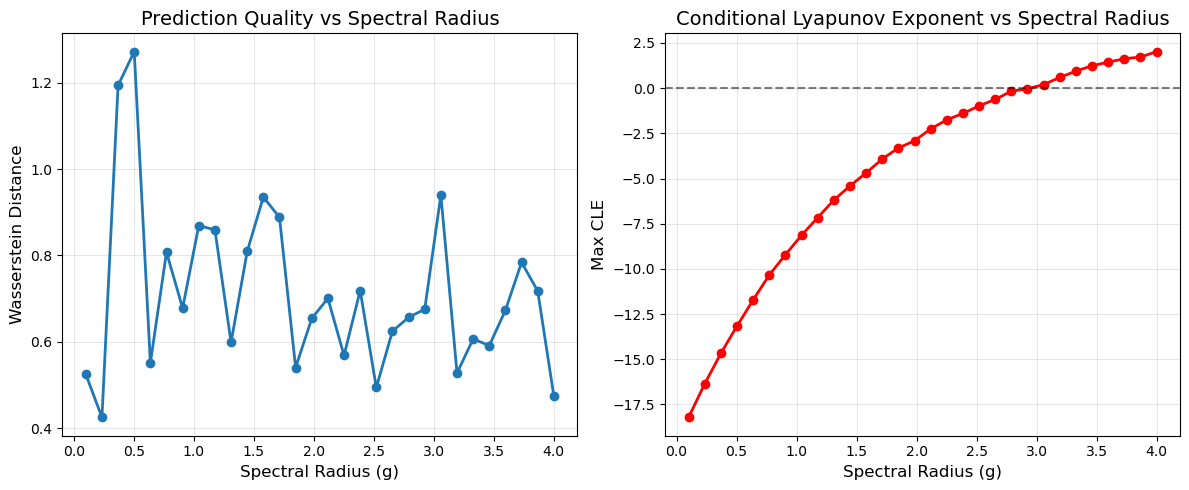

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(results['spectral_radii'], results['wasserstein_distances'], 'o-', linewidth=2, markersize=6)
axes[0].set_xlabel('Spectral Radius (g)', fontsize=12)
axes[0].set_ylabel('Wasserstein Distance', fontsize=12)
axes[0].set_title('Prediction Quality vs Spectral Radius', fontsize=14)
axes[0].grid(True, alpha=0.3)

axes[1].plot(results['spectral_radii'], results['max_cle'], 'o-', linewidth=2, markersize=6, color='red')
axes[1].set_xlabel('Spectral Radius (g)', fontsize=12)
axes[1].set_ylabel('Max CLE', fontsize=12)
axes[1].set_title('Conditional Lyapunov Exponent vs Spectral Radius', fontsize=14)
axes[1].axhline(y=0, color='k', linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()